<a href="https://colab.research.google.com/github/smunazza/53_Munazza-Sayed_Assignment1/blob/main/davassignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error




In [15]:
import yfinance as yf

df = yf.download("DIVISLAB.NS", period="1y")
df.head()

/tmp/ipykernel_3022/4114806363.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("DIVISLAB.NS", period="1y")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,DIVISLAB.NS,DIVISLAB.NS,DIVISLAB.NS,DIVISLAB.NS,DIVISLAB.NS
Date,,,,,
2025-04-17,5614.435059,5771.718878,5570.634501,5723.936452,531948
2025-04-21,5864.795410,5893.166227,5772.714688,5823.483519,717346
2025-04-22,5884.704590,5991.219585,5796.605739,5857.826974,666774
2025-04-23,5897.645508,5947.916602,5864.795090,5900.134176,637067
2025-04-24,6187.326660,6279.905114,5926.514242,5955.382792,2081063


In [16]:
# DATA PREPROCESSING
df.index = pd.to_datetime(df.index)
print(df.isnull().sum())
df.fillna(method='ffill', inplace=True)

Price   Ticker     
Close   DIVISLAB.NS    0
High    DIVISLAB.NS    0
Low     DIVISLAB.NS    0
Open    DIVISLAB.NS    0
Volume  DIVISLAB.NS    0
dtype: int64


/tmp/ipykernel_3022/2796004591.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


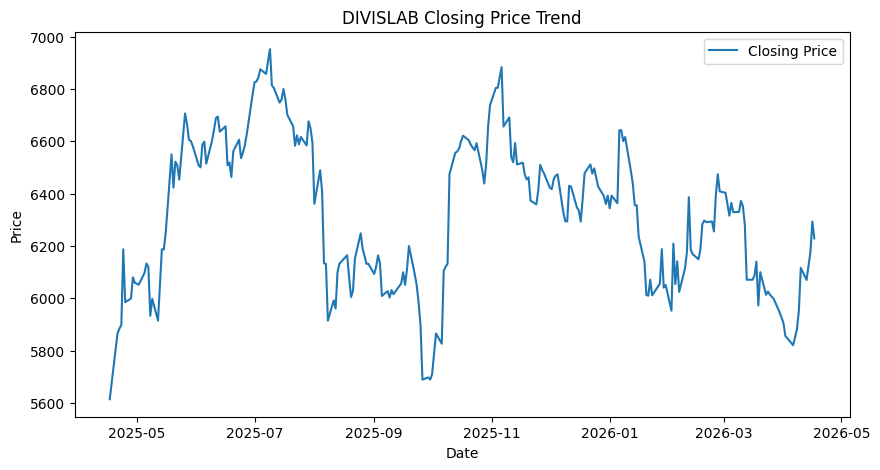

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Closing Price')

plt.title('DIVISLAB Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.show()

In [18]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.886296231601594
p-value: 0.046964923937601405


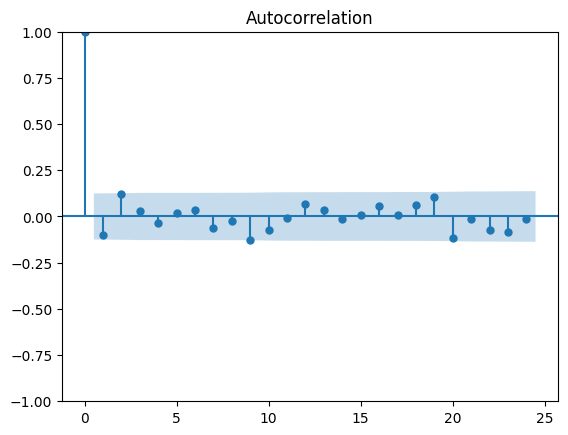

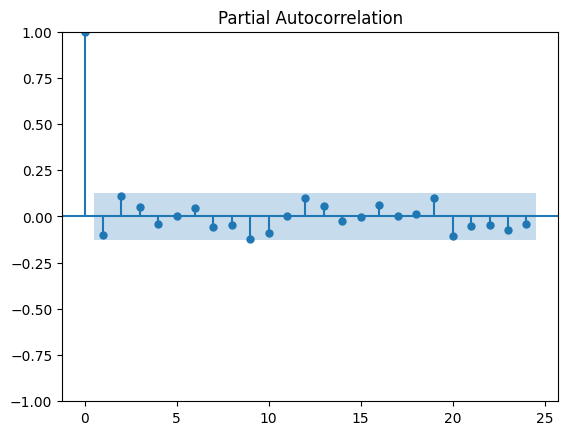

In [20]:
d = 1
df_diff = df['Close'].diff().dropna()

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_acf(df_diff)
plot_pacf(df_diff)
plt.show()

In [21]:
(p, d, q) = (1, 1, 1)

from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Close'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            DIVISLAB.NS   No. Observations:                  248
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1469.300
Date:                Sun, 19 Apr 2026   AIC                           2944.600
Time:                        09:10:37   BIC                           2955.128
Sample:                             0   HQIC                          2948.838
                                - 248                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5037      0.398     -1.264      0.206      -1.285       0.277
ma.L1          0.4010      0.428      0.937      0.349      -0.438       1.240
sigma2      8588.4457    561.422     15.298      0.0

In [22]:
from sklearn.metrics import mean_squared_error
import numpy as np

pred = model_fit.fittedvalues

rmse = np.sqrt(mean_squared_error(df['Close'][1:], pred[1:]))
print("RMSE:", rmse)

RMSE: 92.74236707456544


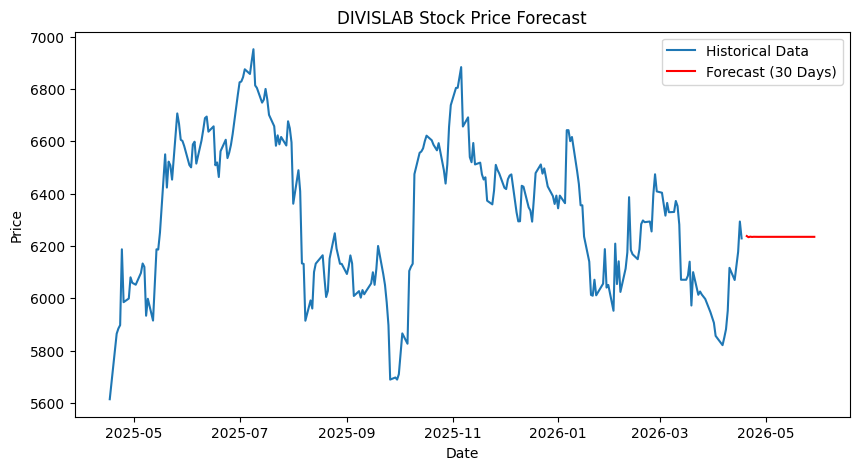

In [28]:
import pandas as pd

# Last date from your dataset
last_date = df.index[-1]

# Create next 30 business days
future_dates = pd.date_range(start=last_date, periods=31, freq='B')[1:]

forecast.index = future_dates


# FORECASTING PLOT

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df['Close'], label='Historical Data')
plt.plot(forecast, label='Forecast (30 Days)', color='red')

plt.title('DIVISLAB Stock Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.show()